#  Projet Machine Learning - Prédiction de survie du Titanic

**Objectif :** Utiliser plusieurs algorithmes de ML pour prédire si un passager du Titanic a survécu.

**Réaliser par  :** CHAYMAE LAHMAMA



In [1]:
#CELLULE 2 : Import des bibliothèques
# Installation d'une bibliothèque supplémentaire (si besoin)
!pip install -q kaggle

# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Pour ignorer les avertissements (rend le notebook plus propre)
import warnings
warnings.filterwarnings('ignore')

# Pour améliorer l'affichage
pd.set_option('display.max_columns', None)

print(" Toutes les bibliothèques sont importées avec succès!")

 Toutes les bibliothèques sont importées avec succès!


In [2]:
#CELLULE 3 : Upload du fichier Titanic
from google.colab import files

print(" Veuillez sélectionner le fichier train.csv téléchargé depuis Kaggle")

uploaded = files.upload()

import io
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print("\n Fichier chargé avec succès!")
print(f" Dimension du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")

 Veuillez sélectionner le fichier train.csv téléchargé depuis Kaggle


Saving train.csv to train.csv

 Fichier chargé avec succès!
 Dimension du dataset : 891 lignes, 12 colonnes


In [3]:
#CELLULE 4 : Exploration rapide des données
# Afficher les 5 premières lignes
print(" Aperçu des données :")
df.head()

# Informations sur les colonnes
print(" Types de données et valeurs manquantes :")
df.info()

# Statistiques descriptives
print(" Statistiques des variables numériques :")
df.describe()

# Vérification des valeurs manquantes
print(" Valeurs manquantes par colonne :")
print(df.isnull().sum())


 Aperçu des données :
 Types de données et valeurs manquantes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
 Statistiques des variables numériques :
 Valeurs manquantes par colonne :
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age       

In [4]:
#CELLULE 5 : Nettoyage des données
# Copie de sécurité
df_original = df.copy()

# 1. Supprimer les colonnes inutiles
df.drop(['PassengerId', 'Ticket', 'Cabin'], axis=1, inplace=True)

# 2. Remplir l'âge manquant par la médiane
df['Age'].fillna(df['Age'].median(), inplace=True)

# 3. Remplir le port d'embarquement manquant par le plus fréquent
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# 4. Vérifier qu'il n'y a plus de valeurs manquantes
print(" Après nettoyage - Valeurs manquantes :")
print(df.isnull().sum())

print(f"\n Nouvelle dimension : {df.shape}")
df.head()

 Après nettoyage - Valeurs manquantes :
Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

 Nouvelle dimension : (891, 9)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


In [ ]:
#CELLULE 6 : Création de nouvelles features
# 1. Taille de la famille
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. Est-ce que le passager est seul ?
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 3. Extraire le titre du nom
df['Title'] = df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())

# Regrouper les titres rares
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr',
                                    'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# 4. Supprimer la colonne Name originale
df.drop('Name', axis=1, inplace=True)

print(" Nouvelles features créées !")
df.head()


 Nouvelles features créées !


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
0,0,3,male,22.0,1,0,7.2500,S,2,0,Mr
1,1,1,female,38.0,1,0,71.2833,C,2,0,Mrs
2,1,3,female,26.0,0,0,7.9250,S,1,1,Miss
3,1,1,female,35.0,1,0,53.1000,S,2,0,Mrs
4,0,3,male,35.0,0,0,8.0500,S,1,1,Mr


📊 Taux de survie global : 38.38%


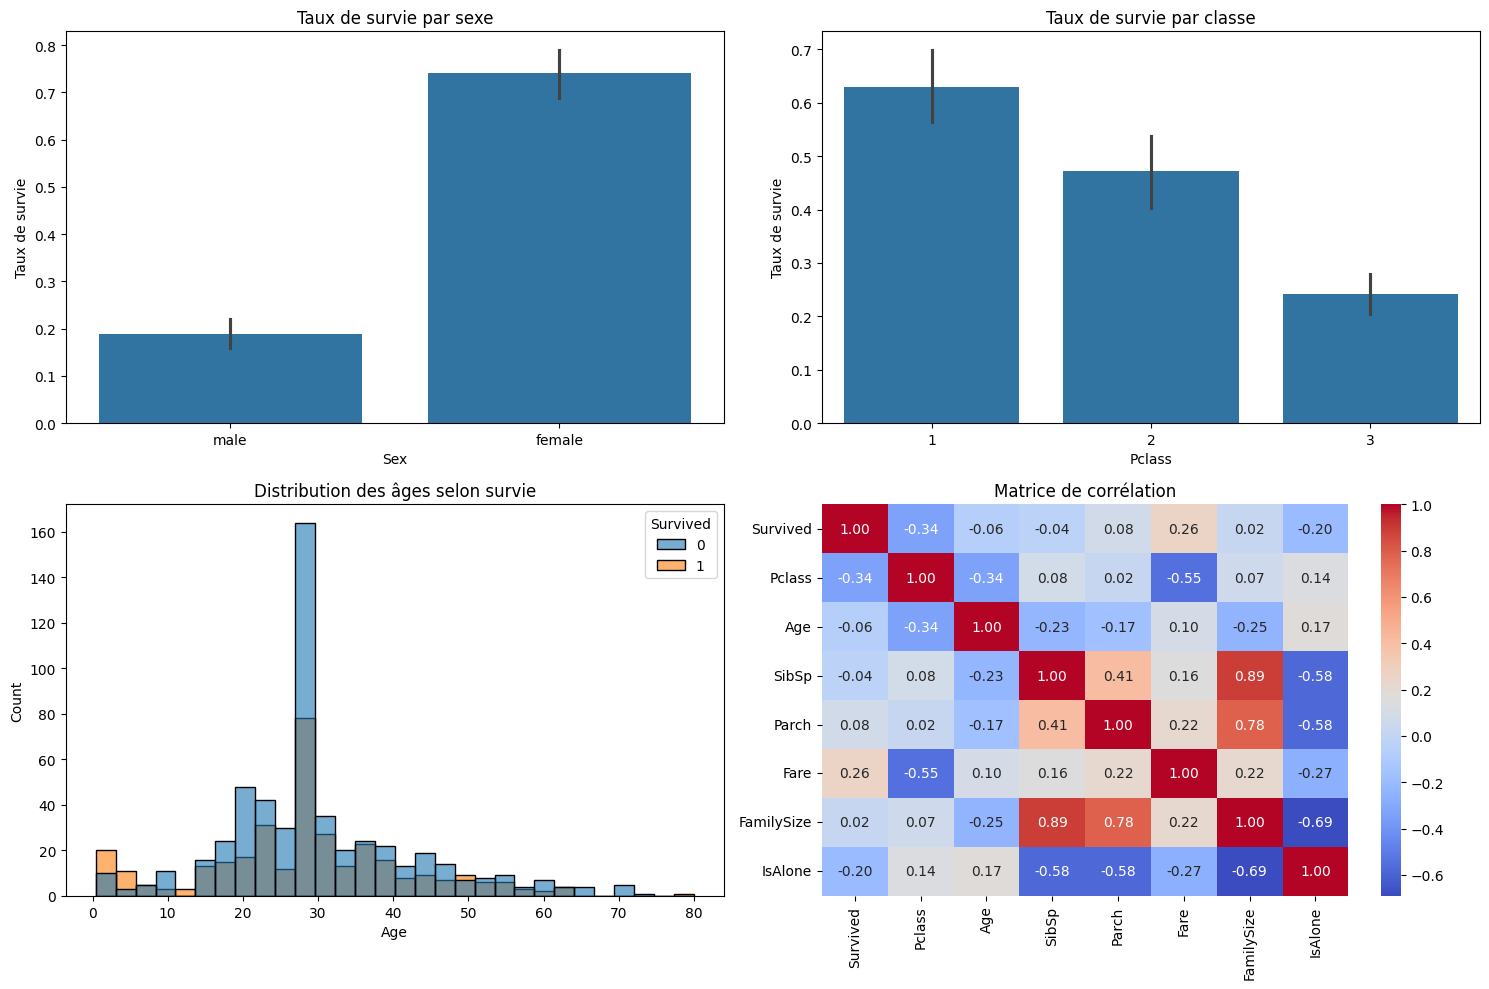

In [ ]:
#CELLULE 7 : Visualisations (graphiques)
# Taux de survie global
survival_rate = df['Survived'].mean() * 100
print(f" Taux de survie global : {survival_rate:.2f}%")

# Configuration des graphiques
plt.figure(figsize=(15, 10))

# Graphique 1 : Survie par sexe
plt.subplot(2, 2, 1)
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Taux de survie par sexe')
plt.ylabel('Taux de survie')

# Graphique 2 : Survie par classe
plt.subplot(2, 2, 2)
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Taux de survie par classe')
plt.ylabel('Taux de survie')

# Graphique 3 : Distribution des âges
plt.subplot(2, 2, 3)
sns.histplot(data=df, x='Age', hue='Survived', bins=30, alpha=0.6)
plt.title('Distribution des âges selon survie')

# Graphique 4 : Matrice de corrélation
plt.subplot(2, 2, 4)
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation')

plt.tight_layout()
plt.show()

In [ ]:
#CELLULE 8 : Préparation des données pour les modèles
# 1. Encodage des variables catégorielles
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# 2. One-Hot encoding pour les autres variables
df = pd.get_dummies(df, columns=['Embarked', 'Title'], drop_first=True)

# 3. Séparer X (features) et y (cible)
X = df.drop('Survived', axis=1)
y = df['Survived']

print(f" Nombre de features : {X.shape[1]}")
print(f" Nombre d'échantillons : {X.shape[0]}")

# 4. Division train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n Train set : {X_train.shape[0]} échantillons")
print(f" Test set : {X_test.shape[0]} échantillons")

# 5. Normalisation
scaler = StandardScaler()
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("\n Données prêtes pour l'entraînement !")

 Nombre de features : 15
 Nombre d'échantillons : 891

 Train set : 712 échantillons
 Test set : 179 échantillons

 Données prêtes pour l'entraînement !


In [ ]:
#CELLULE 9 : Entraînement de plusieurs modèles
# Liste des modèles à tester
models = {
    'Régression Logistique': LogisticRegression(random_state=42, max_iter=1000),
    'Arbre de Décision': DecisionTreeClassifier(random_state=42),
    'Forêt Aléatoire': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}

print(" Entraînement des modèles...")
print("="*80)

for name, model in models.items():
    # Entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Scores
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)

    # Validation croisée
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    results[name] = {
        'train_acc': train_acc,
        'test_acc': test_acc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }

    print(f"\n {name}")
    print(f"   Exactitude Train : {train_acc:.4f}")
    print(f"   Exactitude Test  : {test_acc:.4f}")
    print(f"   Cross-Validation : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Tableau comparatif
results_df = pd.DataFrame(results).T
print("\n" + "="*80)
print(" TABLEAU COMPARATIF")
print("="*80)
print(results_df[['train_acc', 'test_acc', 'cv_mean']].round(4))

 Entraînement des modèles...

 Régression Logistique
   Exactitude Train : 0.8258
   Exactitude Test  : 0.8212
   Cross-Validation : 0.8161 (+/- 0.0174)

 Arbre de Décision
   Exactitude Train : 0.9831
   Exactitude Test  : 0.8324
   Cross-Validation : 0.7571 (+/- 0.0197)

 Forêt Aléatoire
   Exactitude Train : 0.9831
   Exactitude Test  : 0.8101
   Cross-Validation : 0.7923 (+/- 0.0443)

 Gradient Boosting
   Exactitude Train : 0.9129
   Exactitude Test  : 0.8268
   Cross-Validation : 0.8189 (+/- 0.0227)

 SVM
   Exactitude Train : 0.8357
   Exactitude Test  : 0.8268
   Cross-Validation : 0.8217 (+/- 0.0139)

 KNN
   Exactitude Train : 0.8581
   Exactitude Test  : 0.8212
   Cross-Validation : 0.8020 (+/- 0.0240)

 TABLEAU COMPARATIF
                       train_acc  test_acc  cv_mean
Régression Logistique     0.8258    0.8212   0.8161
Arbre de Décision         0.9831    0.8324   0.7571
Forêt Aléatoire           0.9831    0.8101   0.7923
Gradient Boosting         0.9129    0.8268   0.8

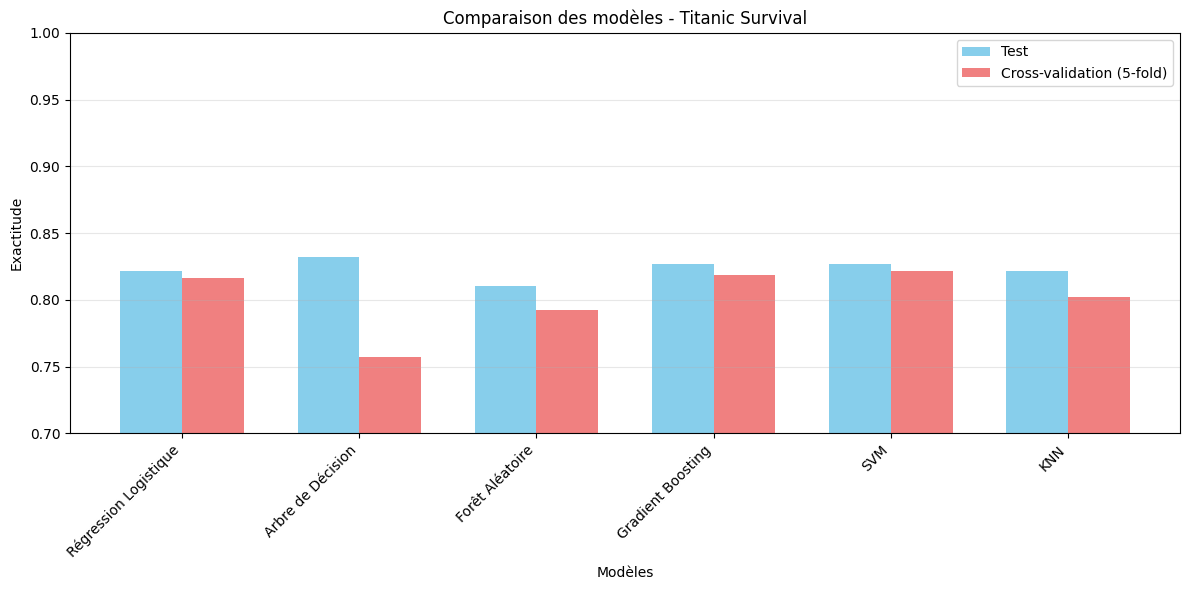

In [ ]:
#CELLULE 10 : Graphique comparatif
# Visualisation des résultats
plt.figure(figsize=(12, 6))

models_names = list(results.keys())
test_scores = [results[m]['test_acc'] for m in models_names]
cv_scores = [results[m]['cv_mean'] for m in models_names]

x = np.arange(len(models_names))
width = 0.35

plt.bar(x - width/2, test_scores, width, label='Test', color='skyblue')
plt.bar(x + width/2, cv_scores, width, label='Cross-validation (5-fold)', color='lightcoral')

plt.xlabel('Modèles')
plt.ylabel('Exactitude')
plt.title('Comparaison des modèles - Titanic Survival')
plt.xticks(x, models_names, rotation=45, ha='right')
plt.legend()
plt.ylim(0.7, 1.0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

 MEILLEUR MODÈLE : Arbre de Décision
 Exactitude sur le test set : 0.8324 (83.24%)

 RAPPORT DÉTAILLÉ
Précision (Precision) : 0.7910
Rappel (Recall) : 0.7681
F1-Score : 0.7794


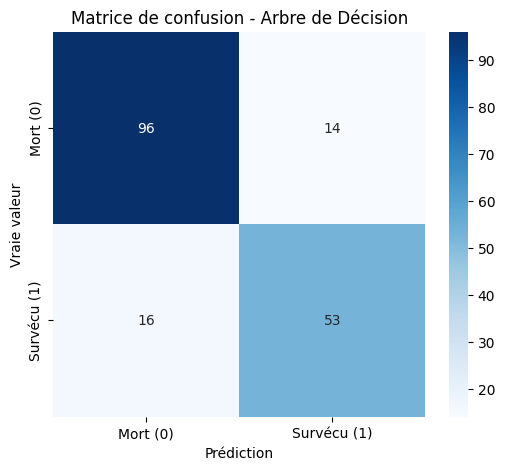


 Classification Report :
              precision    recall  f1-score   support

        Mort       0.86      0.87      0.86       110
     Survécu       0.79      0.77      0.78        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



In [ ]:
#CELLULE 11 : Meilleur modèle et évaluation détaillée
# Identifier le meilleur modèle
best_model_name = results_df['test_acc'].idxmax()
best_test_score = results_df.loc[best_model_name, 'test_acc']

print(f" MEILLEUR MODÈLE : {best_model_name}")
print(f" Exactitude sur le test set : {best_test_score:.4f} ({best_test_score*100:.2f}%)")

# Réentraîner le meilleur modèle
best_model = models[best_model_name]
best_model.fit(X_train, y_train)
y_pred_final = best_model.predict(X_test)

# Métriques détaillées
print("\n RAPPORT DÉTAILLÉ")
print("="*60)
print(f"Précision (Precision) : {precision_score(y_test, y_pred_final):.4f}")
print(f"Rappel (Recall) : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_final):.4f}")

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Mort (0)', 'Survécu (1)'],
            yticklabels=['Mort (0)', 'Survécu (1)'])
plt.title(f'Matrice de confusion - {best_model_name}')
plt.ylabel('Vraie valeur')
plt.xlabel('Prédiction')
plt.show()

# Classification report détaillé
print("\n Classification Report :")
print(classification_report(y_test, y_pred_final, target_names=['Mort', 'Survécu']))

In [ ]:
#CELLULE 12 : Conclusion
print("="*80)
print(" CONCLUSION DU PROJET")
print("="*80)

print(f"""
 OBJECTIF ATTEINT : Prédire la survie des passagers du Titanic

 RÉSULTATS CLÉS :
- Meilleur modèle : {best_model_name}
- Exactitude : {best_test_score*100:.2f}%
- Précision : {precision_score(y_test, y_pred_final):.4f}
- Rappel : {recall_score(y_test, y_pred_final):.4f}

 FACTEURS LES PLUS IMPORTANTS  :
- Le sexe (les femmes ont plus survécu)
- La classe sociale (1ère classe mieux traitée)
- L'âge (les enfants ont été prioritaires)


 Projet réalisé sur Google Colab
""")

 CONCLUSION DU PROJET

 OBJECTIF ATTEINT : Prédire la survie des passagers du Titanic

 RÉSULTATS CLÉS :
- Meilleur modèle : Arbre de Décision
- Exactitude : 83.24%
- Précision : 0.7910
- Rappel : 0.7681

 FACTEURS LES PLUS IMPORTANTS  :
- Le sexe (les femmes ont plus survécu)
- La classe sociale (1ère classe mieux traitée)
- L'âge (les enfants ont été prioritaires)


 Projet réalisé sur Google Colab

